Challenge 6a (tol = 1e-06)
Jacobi converged: True iterations: 19 time (sec): 0.0023775529116392136 x: [0.99999995 2.00000025 2.99999986 4.00000008 4.99999983]
Gauss-Seidel converged: True iterations: 11 time (sec): 0.001346382312476635 x: [1.00000003 2.00000002 2.99999999 3.99999998 5.        ]
Challenge 6b (tol = 1e-06)
Jacobi converged: False iterations: 200 time (sec): 0.023495737463235855 x: [-4.85208192e+170 -6.01093850e+170 -7.48252362e+170 -6.01093850e+170
 -4.85208192e+170]
Gauss-Seidel converged: False iterations: 200 time (sec): 0.025757761672139168 x: [-4.04548280e+226  8.96940629e+226  3.21591269e+226 -2.91483874e+227
  4.86490367e+227]


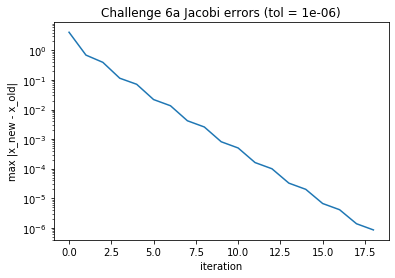

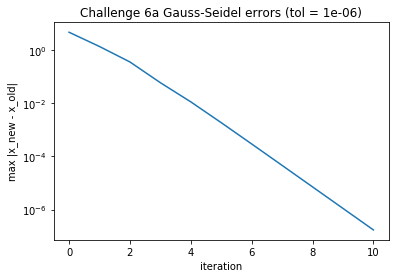

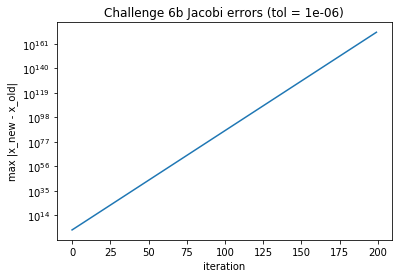

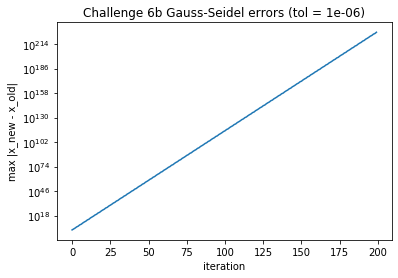

In [171]:
import numpy as np
import matplotlib.pyplot as plt
import time

A_6a = np.array([[10, -1, 2, 0, 0],
                 [-1, 11, -1, 3, 0],
                 [2, -1, 10, -1, 0],
                 [0, 3, -1, 8, -2],
                 [0, 0, 0, -2, 9]])

b_6a = np.array([14, 30, 26, 25, 37])

A_6b = np.array([[1, 2, 3, 0, 0],
                 [2, 1, 2, 3, 0],
                 [3, 2, 1, 2, 3],
                 [0, 3, 2, 1, 2],
                 [0, 0, 3, 2, 1]])

b_6b = np.array([14, 22, 33, 26, 22])

tol = np.array([10**-6])

def Jacobi(A, b, tol, errors):
    errors_by_tol = []
    iters_by_tol = []
    times_by_tol = []
    x_by_tol = []
    converged_by_tol = []

    maxIter = 200

    for k in range(tol.shape[0]):

        isConverged = False
        isDiverged = False
        x = np.zeros(A.shape[0])
        errors = []
        iterations = 0

        start = time.perf_counter()

        while((not isConverged) and (not isDiverged) and (iterations < maxIter)):
            x_update = np.zeros(A.shape[0])

            ATermsArray = np.zeros(A.shape[0])

            for i in range(A.shape[0]):

                for j in range(A.shape[1]):
                    if (i == j):
                        continue

                    ATermsArray[i] += A[i][j]*(x[j])

                x_update[i] = (b[i] - ATermsArray[i])/A[i][i]


            if (not np.all(np.isfinite(x_update))):
                isDiverged = True
                break


            changes = np.zeros(A.shape[0])
            for i in range (A.shape[0]):
                changes[i] = x_update[i] - x[i]


            err = np.max(np.abs(changes))

            if (not np.isfinite(err)):
                isDiverged = True
                break


            if err < tol[k]:
                isConverged = True

            errors.append(err)

            x = x_update
            iterations += 1

        end = time.perf_counter()

        errors_by_tol.append(errors)
        iters_by_tol.append(iterations)
        times_by_tol.append(end - start)
        x_by_tol.append(x)
        converged_by_tol.append(isConverged)

    return errors_by_tol, iters_by_tol, times_by_tol, x_by_tol, converged_by_tol


def GaussSeidel(A, b, tol, errors):
    errors_by_tol = []
    iters_by_tol = []
    times_by_tol = []
    x_by_tol = []
    converged_by_tol = []

    maxIter = 200

    for k in range(tol.shape[0]):

        isConverged = False
        isDiverged = False
        x = np.zeros(A.shape[0])
        errors = []
        iterations = 0

        start = time.perf_counter()

        while((not isConverged) and (not isDiverged) and (iterations < maxIter)):
            x_update = np.zeros(A.shape[0])

            ATermsArray = np.zeros(A.shape[0])

            for i in range(A.shape[0]):

                for j in range(A.shape[1]):
                    if (i == j):
                        continue
                    if (j < i):
                        ATermsArray[i] += A[i][j]*(x_update[j])
                    else:
                        ATermsArray[i] += A[i][j]*(x[j])

                x_update[i] = (b[i] - ATermsArray[i])/A[i][i]


            if (not np.all(np.isfinite(x_update))):
                isDiverged = True
                break


            changes = np.zeros(A.shape[0])
            for i in range (A.shape[0]):
                changes[i] = x_update[i] - x[i]


            err = np.max(np.abs(changes))

            if (not np.isfinite(err)):
                isDiverged = True
                break


            if err < tol[k]:
                isConverged = True

            errors.append(err)

            x = x_update
            iterations += 1

        end = time.perf_counter()

        errors_by_tol.append(errors)
        iters_by_tol.append(iterations)
        times_by_tol.append(end - start)
        x_by_tol.append(x)
        converged_by_tol.append(isConverged)

    return errors_by_tol, iters_by_tol, times_by_tol, x_by_tol, converged_by_tol


jacobi_errors_6a = []
gs_errors_6a = []
jacobi_errors_6b = []
gs_errors_6b = []

jacobi_errors_6a, jacobi_iters_6a, jacobi_times_6a, jacobi_x_6a, jacobi_conv_6a = Jacobi(A_6a, b_6a, tol, jacobi_errors_6a)
gs_errors_6a, gs_iters_6a, gs_times_6a, gs_x_6a, gs_conv_6a = GaussSeidel(A_6a, b_6a, tol, gs_errors_6a)

jacobi_errors_6b, jacobi_iters_6b, jacobi_times_6b, jacobi_x_6b, jacobi_conv_6b = Jacobi(A_6b, b_6b, tol, jacobi_errors_6b)
gs_errors_6b, gs_iters_6b, gs_times_6b, gs_x_6b, gs_conv_6b = GaussSeidel(A_6b, b_6b, tol, gs_errors_6b)

for k in range(tol.shape[0]):
    print("Challenge 6a (tol = " + str(tol[k]) + ")")
    print("Jacobi converged:", jacobi_conv_6a[k], "iterations:", jacobi_iters_6a[k], "time (sec):", jacobi_times_6a[k], "x:", jacobi_x_6a[k])
    print("Gauss-Seidel converged:", gs_conv_6a[k], "iterations:", gs_iters_6a[k], "time (sec):", gs_times_6a[k], "x:", gs_x_6a[k])

for k in range(tol.shape[0]):
    print("Challenge 6b (tol = " + str(tol[k]) + ")")
    print("Jacobi converged:", jacobi_conv_6b[k], "iterations:", jacobi_iters_6b[k], "time (sec):", jacobi_times_6b[k], "x:", jacobi_x_6b[k])
    print("Gauss-Seidel converged:", gs_conv_6b[k], "iterations:", gs_iters_6b[k], "time (sec):", gs_times_6b[k], "x:", gs_x_6b[k])

for k in range(tol.shape[0]):
    if len(jacobi_errors_6a[k]) > 0:
        plt.figure()
        xVal = np.arange(0, len(jacobi_errors_6a[k]))
        plt.plot(xVal, jacobi_errors_6a[k])
        plt.yscale("log")
        plt.title("Challenge 6a Jacobi errors (tol = " + str(tol[k]) + ")")
        plt.xlabel("iteration")
        plt.ylabel("max |x_new - x_old|")

for k in range(tol.shape[0]):
    if len(gs_errors_6a[k]) > 0:
        plt.figure()
        xVal = np.arange(0, len(gs_errors_6a[k]))
        plt.plot(xVal, gs_errors_6a[k])
        plt.yscale("log")
        plt.title("Challenge 6a Gauss-Seidel errors (tol = " + str(tol[k]) + ")")
        plt.xlabel("iteration")
        plt.ylabel("max |x_new - x_old|")

for k in range(tol.shape[0]):
    if len(jacobi_errors_6b[k]) > 0:
        plt.figure()
        xVal = np.arange(0, len(jacobi_errors_6b[k]))
        plt.plot(xVal, jacobi_errors_6b[k])
        plt.yscale("log")
        plt.title("Challenge 6b Jacobi errors (tol = " + str(tol[k]) + ")")
        plt.xlabel("iteration")
        plt.ylabel("max |x_new - x_old|")

for k in range(tol.shape[0]):
    if len(gs_errors_6b[k]) > 0:
        plt.figure()
        xVal = np.arange(0, len(gs_errors_6b[k]))
        plt.plot(xVal, gs_errors_6b[k])
        plt.yscale("log")
        plt.title("Challenge 6b Gauss-Seidel errors (tol = " + str(tol[k]) + ")")
        plt.xlabel("iteration")
        plt.ylabel("max |x_new - x_old|")

plt.show()

Challenge 6B seems to diverge as we add iterations, so i guess the time for it to converge through either jacobi or gauss seidel is infinity?